In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rfmodel.core.signal import Signal
from rfmodel.comms.pseudorandom_NGR import PRBSBitSource, PRBSParams
from rfmodel.plot_utils import plot_bits

In [2]:
# --------------------------------------------------
# Parameters
# --------------------------------------------------
M = 64
bits_per_symbol = int(np.log2(M))   # 6 for 64-QAM

fs_hz = 20e6
n_data_subcarriers = 52
n_ofdm_symbols = 4

n_qam_symbols = n_ofdm_symbols * n_data_subcarriers
n_bits = n_qam_symbols * bits_per_symbol

# --------------------------------------------------
# Generate PRBS bits
# --------------------------------------------------
dummy = Signal(
    x=np.array([], dtype=np.uint8),
    fs_hz=fs_hz,
    fc_hz=0.0,
    meta={}
)

Number of bits: 1248
Expected QAM symbols: 208
Bits per symbol: 6
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0]
{'source': 'PRBS15', 'prbs_order': 15, 'n_bits': 1248, 'seed': 1}


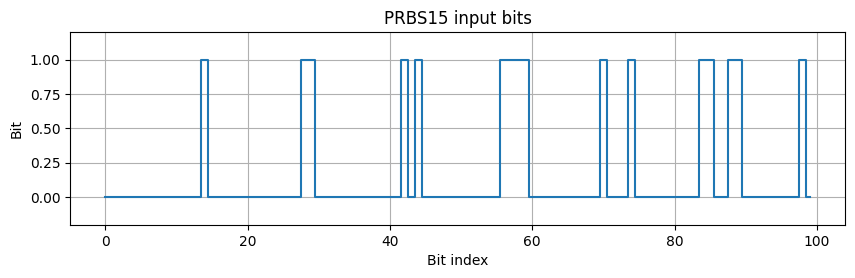

In [6]:
prbs = PRBSBitSource(
    name="tx_bits",
    params=PRBSParams(
        order=15,
        n_bits=n_bits,
        seed=1,
    ),
)

sig_bits = prbs.process(dummy)

print("Number of bits:", len(sig_bits.x))
print("Expected QAM symbols:", n_qam_symbols)
print("Bits per symbol:", bits_per_symbol)
print(sig_bits.x[:32])
print(sig_bits.meta)

plot_bits(sig_bits.x, n_bits=100, title="PRBS15 input bits")